In [1]:
from IPython.display import display
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm import tqdm

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models


In [ ]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Path to attributes file
attr_file = os.path.join(PROJECT_ROOT, "Dataset", "list_attr_celeba.txt")
image_dir = os.path.join(PROJECT_ROOT, "Dataset", "img_align_celeba")  #cleaned file

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 0. Preprocessing : Detection and isolation of corrupted images (Offline)

The dataset originally contained a few corrupted images which could interrupt the training process. 
A separate script (`extract_corrupted_images.py`) was used to verify all images using the PIL library. Identified corrupted files were moved to a separate directory (`corrupted_images`) to ensure a clean dataset for the training pipeline. This step is performed once offline.


## 1. Attribute preprocessing & MLP (sanity checks)

In [3]:
# Creation of one-hot vectors for each image

# Images really present
existing_images = set(os.listdir(image_dir))

# Read the lines
with open(attr_file, 'r') as f:
    lines = f.readlines()

# The first line is the number of images, the second one is the name of the attributes
attr_names = lines[1].strip().split()

filtered_attributes = []
filtered_image_names = []

for line in lines[2:]:
    parts = line.strip().split()
    image_name = parts[0]

    # Filter 
    if image_name not in existing_images:
        continue
    attrs = [1.0 if x == "1" else 0.0 for x in parts[1:]]
    filtered_image_names.append(image_name)
    filtered_attributes.append(attrs)

filtered_attributes = torch.tensor(filtered_attributes)

# Save for the MLP
torch.save(filtered_attributes, "celeba_attributes.pt")
torch.save(filtered_image_names, "celeba_image_names.pt")

print("Cleaned dataset")
print("Number of images :", len(filtered_image_names))
print("Attributes shape :", filtered_attributes.shape)

Cleaned dataset
Number of images : 202580
Attributes shape : torch.Size([202580, 40])


Shape of the attributes tensor : torch.Size([202580, 40])
Number of images : 202580


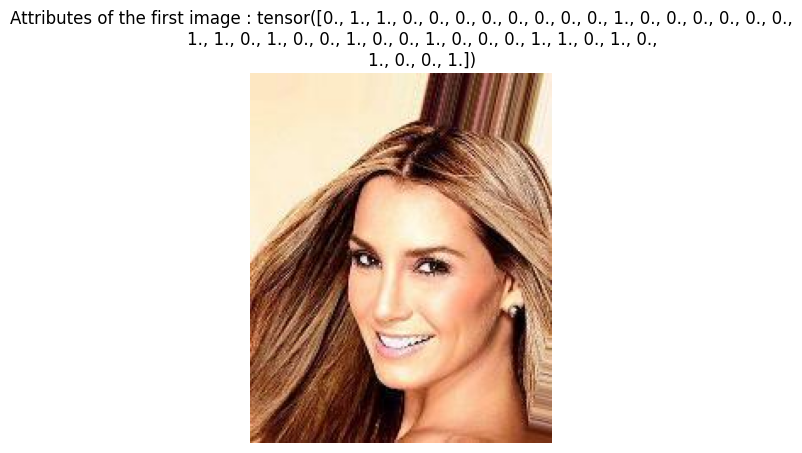

In [4]:
# We check that the vectors were correctly created

# Codes directory
CODES_DIR = os.path.join(PROJECT_ROOT, 'codes')

# Images directory 
IMG_DIR = image_dir

# .pt files
ATTR_FILE = os.path.join(CODES_DIR, 'celeba_attributes.pt')
NAME_FILE = os.path.join(CODES_DIR, 'celeba_image_names.pt')

# Load the files
attrs = torch.load(ATTR_FILE)
names = torch.load(NAME_FILE)

print("Shape of the attributes tensor :", attrs.shape)
print("Number of images :", len(names))

# Display the first image with its attributes
first_img_name = names[0]
img_path = os.path.join(IMG_DIR, first_img_name)
image = Image.open(img_path)

plt.imshow(image)
plt.axis("off")
plt.title(f"Attributes of the first image : {attrs[0]}")
plt.show()

In [5]:
# Creation of the MLP to transform the attributes in 300d embeddings

# Load the attributes vectors
attrs = torch.load("celeba_attributes.pt")
print('Shape of the attributes vectors :', attrs.shape)

# Define the MLP
class AttributeMLP(nn.Module):
    def __init__(self, input_dim=40, embedding_dim=300):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate the MLP
mlp = AttributeMLP()

# Example: forward pass with a batch of 5 images 
sample_attrs = attrs[:5] #takes the 5 first vectors
embeddings = mlp(sample_attrs.float()) 

print('Shape of the embeddings :', embeddings.shape)
print('Embedding example :', embeddings[0])

Shape of the attributes vectors : torch.Size([202580, 40])
Shape of the embeddings : torch.Size([5, 300])
Embedding example : tensor([-1.4347e-01,  2.4016e-02,  7.8346e-02, -3.3148e-02, -3.0153e-02,
         5.0310e-02, -6.7932e-03,  4.4817e-02,  7.3899e-02,  8.3238e-03,
         9.7509e-02,  1.2148e-02, -1.3667e-02,  1.4767e-02,  1.4267e-01,
        -8.5645e-03, -4.9502e-02,  3.3729e-02, -2.7460e-02,  2.5920e-02,
        -5.4793e-02,  1.0396e-01, -8.0218e-02,  5.9958e-02,  6.1218e-02,
        -3.8166e-02, -1.5891e-02, -1.5523e-04,  1.8665e-02,  2.9582e-02,
        -5.8244e-03,  4.7730e-02,  6.4062e-02,  5.1932e-03,  2.2295e-01,
         1.0163e-01,  9.8773e-02, -2.4026e-02, -9.4313e-03,  3.0018e-02,
        -1.7063e-02, -9.8882e-02, -1.3811e-02, -1.6034e-02,  1.6661e-02,
        -1.6668e-01, -8.5920e-02,  1.4645e-01, -3.1071e-02,  3.8303e-02,
         1.2051e-01, -4.7331e-02, -8.4232e-02,  2.2525e-02, -2.0078e-02,
         8.1101e-02,  5.4725e-02,  9.0819e-03,  1.8847e-01,  1.8822e-02

## 2. Image embedding extraction (offline)

Image embeddings were pre-computed with a pre-trained ResNet50 backbone. 
The computation is performed once and saved to disk (`embeddings_resnet50.pt`) to avoid any expensive recalculation during training.

## 3. Load precomputed image embeddings


In [6]:
data = torch.load('embeddings_resnet50.pt')
image_feats = data['embeddings']
image_names = data['image_names']

attrs = torch.load("celeba_attributes.pt")

print("Embeddings shape :", image_feats.shape)
print("Attributes shape: ", attrs.shape)
print('Number of images: ', len(image_names))

# we check that the first name corresponds to the first embedding
print("Example first file : ", image_names[0])
print("First file attributes :", attrs[0])

Embeddings shape : torch.Size([202580, 2048])
Attributes shape:  torch.Size([202580, 40])
Number of images:  202580
Example first file :  000001.jpg
First file attributes : tensor([0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0.,
        1., 0., 0., 1.])


## 3.5 Train / Validation / Test split

In [7]:
N = image_feats.shape[0]
indices = torch.arange(N)

# 80% train, 20% temp
train_idx, temp_idx = train_test_split(indices, test_size=0.20,random_state=42,shuffle=True)

# 10% val / 10% test
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, shuffle=True)

# Train

image_feats_train = image_feats[train_idx]
attrs_train = attrs[train_idx]

# Validation

image_feats_val = image_feats[val_idx]
attrs_val = attrs[val_idx]

# Test
image_feats_test = image_feats[test_idx]
attrs_test = attrs[test_idx]
image_names_test = [image_names[i] for i in test_idx]

print(f'Train : {len(train_idx)}')
print(f'Val : {len(val_idx)}')
print(f'Test : {len(test_idx)}')

Train : 162064
Val : 20258
Test : 20258


## 4. Joint embedding space (Image + Attributes)

In [8]:
class ImageHead(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=300):
        super().__init__()
        self.fc = nn.Linear(input_dim, embedding_dim)

    def forward(self, x):
        return F.normalize(self.fc(x), dim=1)
    
class AttributeMLP(nn.Module):
    def __init__(self, input_dim=40, embedding_dim=300):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

# Load the pre-computed embeddings of the CNN
data = torch.load('embeddings_resnet50.pt')
image_feats = data['embeddings'].float()
image_names = data['image_names']

# Load the attributes
attrs = torch.load('celeba_attributes.pt').float()

# Instantiate the networks
image_head = ImageHead(input_dim=image_feats.shape[1], embedding_dim=300)
mlp = AttributeMLP()

# Project the CNN embeddings in the 300d common space
emb_images = image_head(image_feats)

# Test a forward to check the dimensions
sample_attrs = attrs[:5]
emb_attrs = mlp(sample_attrs)
print("Embeddings images shape :", emb_images.shape)
print("Embeddings attributes shape :", emb_attrs.shape)

Embeddings images shape : torch.Size([202580, 300])
Embeddings attributes shape : torch.Size([5, 300])


## 5. Metric learning objective

In [9]:
# Triplet loss

def triplet_loss(anchor, positive, negative, margin=0.2):
    """ anchor : (B,D) image embeddings
        positive : (B,D) matching attribute embeddings
        negative : (B,D) non-matching attribute embeddings
    """

    pos_dist = F.pairwise_distance(anchor, positive, p=2)
    neg_dist = F.pairwise_distance(anchor, negative, p=2)
    return torch.mean(F.relu(pos_dist - neg_dist + margin))

# Hard negative generation (from the course website)
import torch

def create_hard_negatives(attributes: torch.Tensor, hard_count: int, max_flips: int = 3) -> torch.Tensor:
    """
    Create hard negatives by flipping a random subset of attributes.

    Args:
        attributes : A tensor of shape (N, D) containing 0s and 1s.
        hard_count : The number of hard negatives to create per sample.
        max_flips  : The maximum number of attributes to flip. Defaults to 3.

    Returns:
        A tensor of shape (N, hard_count, D) containing the hard negatives.

    Example:
    >>> attributes = torch.tensor([[1, 0, 1, 0, 0], [0, 1, 0, 1, 0]])
    >>> create_hard_negatives(attributes, 3)
    tensor([[[0., 0., 1., 1., 0.],
             [1., 1., 1., 0., 0.],
             [1., 0., 1., 0., 1.]],
            [[1., 0., 0., 0., 0.],
             [1., 1., 1., 1., 1.],
             [1., 1., 0., 1., 0.]]])
    """
    
    # Prepare the hard negatives
    hard_negatives = attributes.unsqueeze(1).repeat(1, hard_count, 1).bool()
    shape = hard_negatives.shape # (N, hard_count, D)

    # Randomly select up to 3 attributes to flip
    rand_perm = torch.rand(shape, device=attributes.device).argsort(dim=2)[:, :, :max_flips]

    # Randomly determine the number of attributes to flip for each sample
    num_flips = torch.randint(1, max_flips + 1, (shape[0], shape[1]), device=attributes.device)  # (N, hard_count)

    # Loop over the number of flips and apply them
    for i in range(1, max_flips + 1):

        # Create a mask for where we should flip exactly `i` attributes
        flip_mask = num_flips == i  # (N, hard_count)

        if flip_mask.any():

            # Get the indices to flip
            selected_indices = rand_perm[:, :, :i]  # Get the first `i` attribute indices per sample

            # Get index positions where we need to flip
            batch_idx, hard_idx = torch.nonzero(flip_mask, as_tuple=True)

            # Extract corresponding indices from `selected_indices`
            attr_idx = selected_indices[batch_idx, hard_idx]

            # Apply the flip
            hard_negatives[batch_idx.unsqueeze(1), hard_idx.unsqueeze(1), attr_idx] ^= True

    return hard_negatives.float()

## 6. Joint training (image ↔ attributes)

In [10]:
## 6. Joint training (image ↔ attributes)

# Setup
image_head.train()
mlp.train()

params_to_optimize = list(image_head.parameters()) + list(mlp.parameters())
optimizer = optim.Adam(params_to_optimize, lr= 1e-4)

margin = 0.1
num_epochs = 50
batch_size = 512
hard_count = 1

N_train = len(attrs_train)

# Training loop
for epoch in range(num_epochs):
    epoch_loss = 0.0
    correct_triplets = 0
    total_triplets = 0

    for _ in range(N_train // batch_size):
        batch_idx = random.sample(range(N_train), batch_size)

        # Anchor (image embeddings) - frozen
        #with torch.no_grad():
        anchor = image_head(image_feats_train[batch_idx])

        # Positive (matching attributes)
        pos = mlp(attrs_train[batch_idx])

        # Hard negatives (plausible)
        neg_attrs = create_hard_negatives(attrs_train[batch_idx], hard_count=hard_count)

        #neg_attrs = neg_attrs.squeeze(1)
        #neg = mlp(neg_attrs)    
        neg_attrs_flat = neg_attrs.view(-1, neg_attrs.size(-1))
        neg = mlp(neg_attrs_flat)

        anchor_expanded = anchor.repeat_interleave(hard_count, dim=0)
        pos_expanded = pos.repeat_interleave(hard_count, dim=0)

        # Triplet loss
        #loss = triplet_loss(anchor, pos, neg, margin)
        loss = triplet_loss(anchor_expanded, pos_expanded, neg, margin)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        #pos_dist = F.pairwise_distance(anchor, pos)
        #neg_dist = F.pairwise_distance(anchor, neg)
        pos_dist = F.pairwise_distance(anchor_expanded, pos_expanded)
        neg_dist = F.pairwise_distance(anchor_expanded, neg)

        correct_triplets += torch.sum(pos_dist + margin < neg_dist).item()
        #total_triplets += batch_size
        total_triplets += len(anchor_expanded)
        epoch_loss += loss.item()

    print(
        f"[TRAIN] Epoch {epoch+1}/{num_epochs} "
        f"- Loss: {epoch_loss / (N_train // batch_size):.4f} "
        f"- Correct triplets : {100 * correct_triplets / total_triplets:.1f}%"
    )

[TRAIN] Epoch 1/50 - Loss: 0.0279 - Correct triplets : 65.9%
[TRAIN] Epoch 2/50 - Loss: 0.0178 - Correct triplets : 79.3%
[TRAIN] Epoch 3/50 - Loss: 0.0162 - Correct triplets : 81.3%
[TRAIN] Epoch 4/50 - Loss: 0.0151 - Correct triplets : 82.4%
[TRAIN] Epoch 5/50 - Loss: 0.0148 - Correct triplets : 83.1%
[TRAIN] Epoch 6/50 - Loss: 0.0145 - Correct triplets : 83.5%
[TRAIN] Epoch 7/50 - Loss: 0.0142 - Correct triplets : 83.9%
[TRAIN] Epoch 8/50 - Loss: 0.0138 - Correct triplets : 84.3%
[TRAIN] Epoch 9/50 - Loss: 0.0135 - Correct triplets : 84.6%
[TRAIN] Epoch 10/50 - Loss: 0.0135 - Correct triplets : 84.7%
[TRAIN] Epoch 11/50 - Loss: 0.0132 - Correct triplets : 84.9%
[TRAIN] Epoch 12/50 - Loss: 0.0132 - Correct triplets : 85.0%
[TRAIN] Epoch 13/50 - Loss: 0.0131 - Correct triplets : 85.2%
[TRAIN] Epoch 14/50 - Loss: 0.0130 - Correct triplets : 85.3%
[TRAIN] Epoch 15/50 - Loss: 0.0128 - Correct triplets : 85.5%
[TRAIN] Epoch 16/50 - Loss: 0.0127 - Correct triplets : 85.6%
[TRAIN] Epoch 17/

## 6.5 Validation & Early stopping

In [11]:
mlp.eval()
image_head.eval()

val_hard_count = 3

with torch.no_grad():
    anchor_val = image_head(image_feats_val)
    pos_val = mlp(attrs_val)

    neg_val_attrs = create_hard_negatives(attrs_val, hard_count=val_hard_count)
    #neg_val = mlp(neg_val_attrs.squeeze(1))
    neg_val_flat = neg_val_attrs.view(-1, neg_val_attrs.size(-1))
    neg_val = mlp(neg_val_flat)

    anchor_val_expanded = anchor_val.repeat_interleave(val_hard_count, dim=0)
    pos_val_expanded = pos_val.repeat_interleave(val_hard_count, dim=0)

    val_loss = triplet_loss(anchor_val_expanded, pos_val_expanded, neg_val, margin)

print(f"[VAL] Triplet loss: {val_loss.item():.4f}")

[VAL] Triplet loss: 0.0118


## 7. Image retrieval (inference)

In [12]:
# Image retrieval (inference)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_head = image_head.to(device)
mlp = mlp.to(device)

image_head.eval()
mlp.eval()

# Precompute image embeddings (offline inference)
with torch.no_grad():
    img_emb = image_head(image_feats.to(device))

# Query with attribute vector
query_attr = attrs[0].unsqueeze(0).to(device)

with torch.no_grad():
    query_emb = mlp(query_attr)

# Distance and Top_K retrieval
dists = torch.cdist(query_emb, img_emb)

K = 5
topk_idx = torch.topk(dists, K, largest=False).indices.squeeze(0)

topk_images = [image_names[i] for i in topk_idx]
topk_images

['133157.jpg', '162756.jpg', '142771.jpg', '085836.jpg', '116335.jpg']

## 8. Retrieval evaluation (Precision@K, Recall@K)

In [ ]:
K = 5
SIM_THRESHOLD = 0.75
NUM_QUERIES = 100

device = img_emb.device

# Sub-sample of queries in the test set
query_indices = random.sample(range(len(attrs_test)), NUM_QUERIES)

precisions = []
recalls = []

for q_idx in query_indices:
    query_attr = attrs_test[q_idx].unsqueeze(0).to(device)

    with torch.no_grad():
        query_emb = mlp(query_attr)

    # Retrieval
    dists = torch.cdist(query_emb, img_emb)
    topk_idx = torch.topk(dists, K, largest=False).indices.squeeze(0)

    # Attributs actifs dans la requête
    query_attr_vec = attrs_test[q_idx]
    query_attr_idx = (query_attr_vec == 1).nonzero(as_tuple=True)[0]

    if len(query_attr_idx) ==0:
        continue

    # Relevannce definition : An image is relevant if 75% or more attributes match
    #attr_sim_topk = (attrs[topk_idx] == attrs_test[q_idx]).float().mean(dim=1)
    attr_sim_topk = (attrs[topk_idx][:, query_attr_idx] == query_attr_vec[query_attr_idx]).float().mean(dim=1)

    relevant_topk = attr_sim_topk >= SIM_THRESHOLD

    # Precision@K (approximation)
    precision = relevant_topk.float().mean().item()
    precisions.append(precision)

    # Recall@K (approximation)
    #attr_sim_all = (attrs == attrs_test[q_idx]).float().mean(dim=1)   
    attr_sim_all = (attrs[:, query_attr_idx] == query_attr_vec[query_attr_idx]).float().mean(dim=1)    
    relevant_all = (attr_sim_all >= SIM_THRESHOLD).sum().item()
    recall = relevant_topk.float().sum().item() / max(relevant_all, 1)
    recalls.append(recall)

print(f'Precision@{K}: {sum(precisions)/len(precisions):.3f}')
print(f'Recall@{K}: {sum(recalls)/len(recalls):.4f}')



Precision@5: 0.536
Recall@5: 0.0005


DO NOT DEBUG THIS CELL (VERY LONG AND NOT USEFUL)

In [ ]:
def mean_average_precision(model_img_emb, model_attr_emb, attrs, K=10):
    """
    model_img_emb : (N, 300) embeddings images
    model_attr_emb: function mlp
    attrs          : (N, 40)
    """
    APs = []
    N = attrs.shape[0]
    test_indices = list(range(N))  # toutes les images comme requêtes

    for idx in test_indices:
        query_attr = attrs[idx].unsqueeze(0)
        query_emb = model_attr_emb(query_attr)

        # distances
        dists = torch.cdist(query_emb, model_img_emb)
        topk_idx = torch.topk(dists, K, largest=False).indices.squeeze(0)

        # trouver les positions des images pertinentes
        relevant = (attrs[topk_idx] == attrs[idx]).all(dim=1).float()
        if relevant.sum() == 0:
            APs.append(0.0)
            continue

        # precision cumulée
        cum_prec = torch.cumsum(relevant, dim=0) / (torch.arange(K, device=relevant.device) + 1)
        AP = (cum_prec * relevant).sum() / relevant.sum()
        APs.append(AP.item())

    return sum(APs) / len(APs)

mAP_5 = mean_average_precision(img_emb, mlp, attrs, K=5)
print(f"mAP@5: {mAP_5:.3f}")


## 9. Demo

Query Générée Aléatoire (2 attributs) : ['Sideburns', 'Bags_Under_Eyes']

--- Top-5 Résultats ---

#1 : 064825.jpg (Dist: 0.9586)
 ➤ Attributs demandés trouvés : 0/2 -> Aucun
 Autres attributs visibles : Brown_Hair, High_Cheekbones, Male, Mouth_Slightly_Open, No_Beard...


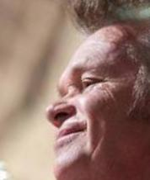


#2 : 006393.jpg (Dist: 0.9709)
 ➤ Attributs demandés trouvés : 2/2 -> ['Sideburns', 'Bags_Under_Eyes']
 Autres attributs visibles : Goatee, Male, Straight_Hair...


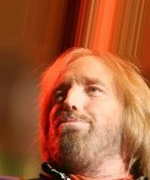


#3 : 058279.jpg (Dist: 0.9710)
 ➤ Attributs demandés trouvés : 2/2 -> ['Sideburns', 'Bags_Under_Eyes']
 Autres attributs visibles : Goatee, Male, Mouth_Slightly_Open, Receding_Hairline...


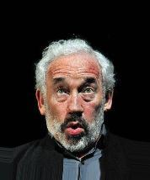


#4 : 074091.jpg (Dist: 0.9744)
 ➤ Attributs demandés trouvés : 0/2 -> Aucun
 Autres attributs visibles : Blurry, Male...


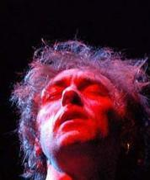


#5 : 114005.jpg (Dist: 0.9749)
 ➤ Attributs demandés trouvés : 1/2 -> ['Sideburns']
 Autres attributs visibles : Gray_Hair, Male...


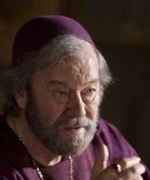

In [24]:
import random
import torch
import torch.nn.functional as F
from PIL import Image
from IPython.display import display

# --- 1. LISTE DES ATTRIBUTS ---
all_attrs = ["5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes",
             "Bald", "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair",
             "Blurry", "Brown_Hair", "Bushy_Eyebrows", "Chubby", "Double_Chin",
             "Eyeglasses", "Goatee", "Gray_Hair", "Heavy_Makeup", "High_Cheekbones",
             "Male", "Mouth_Slightly_Open", "Mustache", "Narrow_Eyes", "No_Beard",
             "Oval_Face", "Pale_Skin", "Pointy_Nose", "Receding_Hairline", "Rosy_Cheeks",
             "Sideburns", "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings",
             "Wearing_Hat", "Wearing_Lipstick", "Wearing_Necklace", "Wearing Necktie", "Young"]

# --- 2. GÉNÉRATION ALÉATOIRE DE LA REQUÊTE ---
# On choisit au hasard entre 2 et 4 attributs pour avoir une requête consistante
num_attrs_to_pick = random.randint(2, 4) 
query_attrs = random.sample(all_attrs, num_attrs_to_pick)

print(f"Query Générée Aléatoire ({len(query_attrs)} attributs) : {query_attrs}")

# Construction du vecteur One-Hot
query_vec = torch.zeros(len(all_attrs), dtype=torch.float32)
for attr in query_attrs:
    query_vec[all_attrs.index(attr)] = 1
query_tensor = query_vec.unsqueeze(0).to(device)

# --- 3. INFERENCE (Recherche) ---
mlp.eval()
image_head.eval()

with torch.no_grad():
    # On projette les attributs
    query_emb = mlp(query_tensor)
    
    # Si img_emb n'est pas déjà calculé/chargé sur le device, on le fait (sinon on utilise celui en mémoire)
    # img_emb doit être de forme [N_images, 300] et normalisé
    if 'img_emb' not in locals():
        print("Calcul des embeddings images (une seule fois)...")
        # On suppose que image_feats est sur le bon device
        img_emb = image_head(image_feats.to(device))

# Calcul des distances
dists = torch.cdist(query_emb, img_emb)

# Récupération du Top-K
K = 5
topk = torch.topk(dists, K, largest=False)
topk_indices = topk.indices.squeeze(0)
topk_distances = topk.values.squeeze(0)

print(f'\n--- Top-{K} Résultats ---')

# --- 4. AFFICHAGE ---
IMAGE_ROOT = "C:/Users/roman/FaceAttributes/img_align_celeba/" # <--- Vérifie ton chemin ici

for rank, idx in enumerate(topk_indices):
    idx = idx.item()
    fname = image_names[idx]
    
    # Récupération des attributs réels de l'image trouvée
    attr_vec_img = attrs[idx]
    active_attrs_img = [all_attrs[j] for j, v in enumerate(attr_vec_img) if v == 1]
    
    # Quels attributs matchent avec la requête ?
    matched_attrs = [a for a in query_attrs if a in active_attrs_img]
    match_count = len(matched_attrs)
    total_query = len(query_attrs)
    
    print(f"\n#{rank+1} : {fname} (Dist: {topk_distances[rank]:.4f})")
    print(f" ➤ Attributs demandés trouvés : {match_count}/{total_query} -> {matched_attrs if matched_attrs else 'Aucun'}")
    # On affiche aussi les autres attributs pour voir si c'est cohérent
    # On coupe la liste si elle est trop longue pour la lisibilité
    others = [a for a in active_attrs_img if a not in matched_attrs]
    print(f" Autres attributs visibles : {', '.join(others[:10])}...")

    try:
        img = Image.open(f"{IMAGE_ROOT}/{fname}")
        display(img.resize((150, 180))) # Resize pour pas prendre tout l'écran
    except FileNotFoundError:
        print(f"   [Image non trouvée sur le disque : {fname}]")

## 10. Saving the model for the website

In [16]:
# Sauvegarde des modèles actuels (ceux qui marchent bien)
torch.save(mlp.state_dict(), "mlp_turbo.pth")
torch.save(image_head.state_dict(), "resnet_turbo.pth")
print("Nouveaux fichiers modèles créés !")

Nouveaux fichiers modèles créés !
